In [ ]:
!unzip "/content/drive/MyDrive/digital_knee_x-ray_ds.zip"

Archive:  /content/drive/MyDrive/digital_knee_x-ray_ds.zip
  inflating: MedicalExpert-I/0Normal/NormalG0 (1).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (10).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (100).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (101).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (102).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (103).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (104).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (105).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (106).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (107).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (108).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (109).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (11).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (110).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (111).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (112).png  
  inflating: Medi

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [ ]:
def read_data(path, image_size, classes):

    X = []
    y = []

    for label in os.listdir(path):
        for image in os.listdir(path + '/' + label):

            img = cv2.imread(path + '/' + label + '/' + image)
            img = cv2.resize(img,(image_size,image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            X.append(img)
            y.append(classes[label])

    return np.array(X), np.array(y)

In [ ]:
knee_classes = {
    '0Normal': 0,
    '1Doubtful': 1,
    '2Mild': 2,
    '3Moderate': 3,
    '4Severe': 4
}

In [ ]:
image_size = 224

x1, y1 = read_data('/content/MedicalExpert-I', image_size, knee_classes)
x2, y2 = read_data('/content/MedicalExpert-II', image_size, knee_classes)

X = np.concatenate((x1, x2))
y = np.concatenate((y1, y2))

X, y = shuffle(X, y, random_state=42)

print("Dataset shape:", X.shape)

Dataset shape: (3300, 224, 224, 3)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [ ]:
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

In [ ]:
y_train = to_categorical(y_train,5)
y_test = to_categorical(y_test,5)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6513157894736842), 1: np.float64(0.7011331444759207), 2: np.float64(1.4473684210526316), 3: np.float64(1.4776119402985075), 4: np.float64(1.4909638554216869)}


In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,694,917 (29.35 MB)

 Trainable params: 1,485,125 (5.67 MB)

 Non-trainable params: 6,209,792 (23.69 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)



In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.2848 - loss: 1.7182 - val_accuracy: 0.3745 - val_loss: 1.3560
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 492ms/step - accuracy: 0.3402 - loss: 1.4884 - val_accuracy: 0.4788 - val_loss: 1.2120
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 496ms/step - accuracy: 0.4190 - loss: 1.3612 - val_accuracy: 0.5394 - val_loss: 1.1093
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 37s 476ms/step - accuracy: 0.4731 - loss: 1.2475 - val_accuracy: 0.5903 - val_loss: 1.0304
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 494ms/step - accuracy: 0.5038 - loss: 1.1832 - val_accuracy: 0.6048 - val_loss: 0.9771
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 499ms/step - accuracy: 0.5531 - loss: 1.1002 - val_accuracy: 0.6279 - val_loss: 0.9301
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 482ms/step - accuracy: 0.5612 - loss: 1.0751 - val_accuracy: 0.6376 - val_loss: 0.8987
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 484ms/step - accuracy: 0.5725 - loss: 1.0394 - val_accura

In [ ]:
model.save("knee_x-ray_densenet_model.h5")

26/26 ━━━━━━━━━━━━━━━━━━━━ 39s 597ms/step


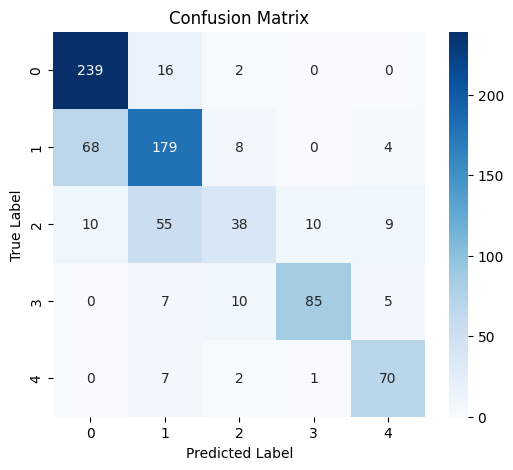

              precision    recall  f1-score   support

           0     0.7539    0.9300    0.8328       257
           1     0.6780    0.6911    0.6845       259
           2     0.6333    0.3115    0.4176       122
           3     0.8854    0.7944    0.8374       107
           4     0.7955    0.8750    0.8333        80

    accuracy                         0.7406       825
   macro avg     0.7492    0.7204    0.7211       825
weighted avg     0.7334    0.7406    0.7255       825



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
# Assuming y_test is one-hot and x_test is your test set
# 1. Get predicted probabilities and class labels
y_pred_proba = model.predict(x_test)                # shape (n_samples, 5)
y_pred = np.argmax(y_pred_proba, axis=1)             # shape (n_samples,)
y_true = np.argmax(y_test, axis=1)                   # shape (n_samples,)
n_classes = y_test.shape[1]

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(n_classes),
            yticklabels=range(n_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. (Optional) Print classification report
print(classification_report(y_true, y_pred, digits=4))

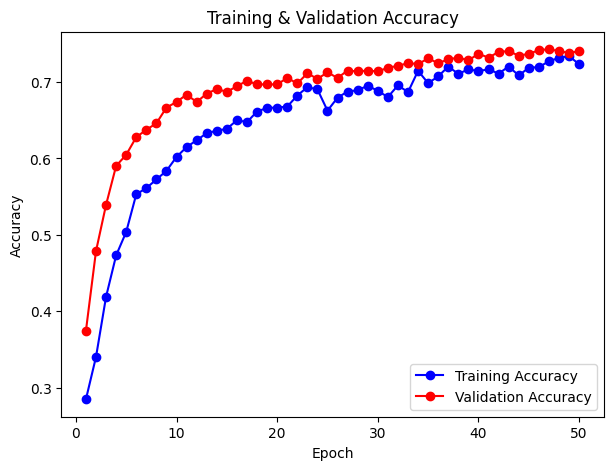

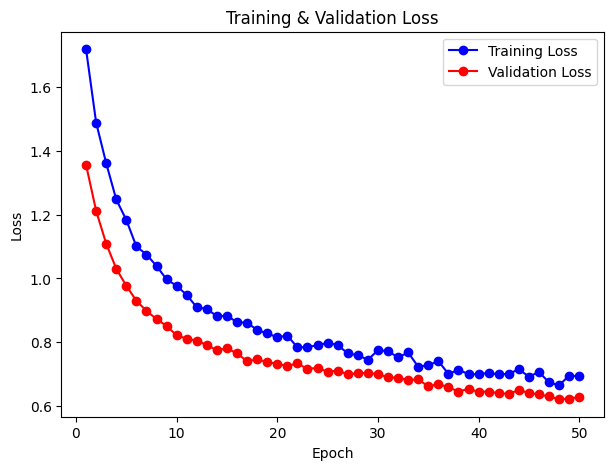

In [ ]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs   = range(1, len(acc) + 1)

# 2. Plot accuracy
plt.figure(figsize=(7,5))
plt.plot(epochs, acc,    'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc,'ro-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 3. Plot loss
plt.figure(figsize=(7,5))
plt.plot(epochs, loss,    'bo-', label='Training Loss')
plt.plot(epochs, val_loss,'ro-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


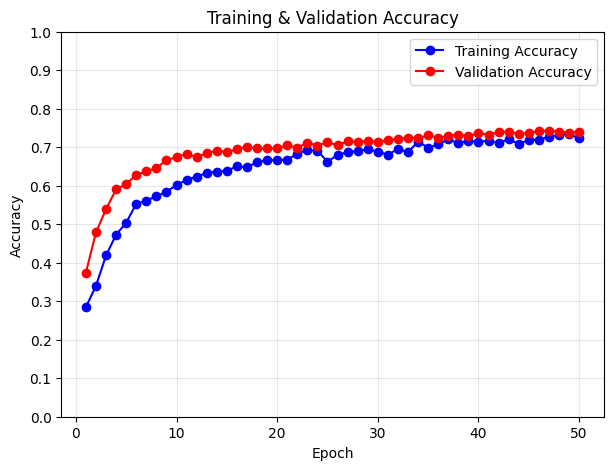

In [ ]:
# 1. Extract metrics from history
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
epochs   = range(1, len(acc) + 1)

# 2. Plot Training & Validation Accuracy over full 0–1 range
plt.figure(figsize=(7,5))
plt.plot(epochs, acc,     'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)              # force y-axis from 0 to 1
plt.yticks(np.linspace(0, 1, 11))  # ticks at every 0.1 step
plt.legend()
plt.grid(alpha=0.3)
plt.show()

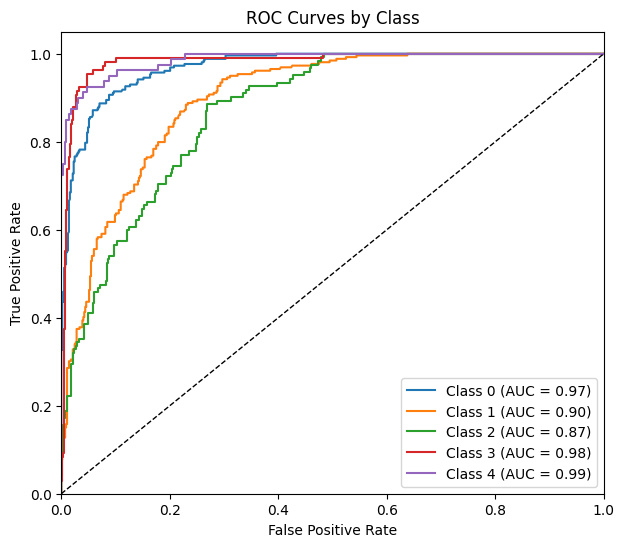

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 2. Plot all ROC curves
plt.figure(figsize=(7,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves by Class')
plt.legend(loc='lower right')
plt.show()